In [15]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

# Data Manipulation & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

# Evaluation Metrics & Interpretability
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

In [16]:
# ==========================================
# 2. DATA LOAD & UNDERSTANDING
# ==========================================
df = pd.read_csv("clothes_price_prediction_data.csv")

print("--- Data Understanding ---")
print(f"Shape dataset: {df.shape[0]} baris, {df.shape[1]} kolom\n")

print("Info Dataset:")
df.info()

print("\nMissing values per kolom:")
print(df.isnull().sum())

print("\n--- Cuplikan Data (5 baris pertama) ---")
display(df.head())

print("\n--- Ringkasan Statistik (Fokus ke kolom numerik/Price) ---")
display(df.describe())

--- Data Understanding ---
Shape dataset: 1000 baris, 6 kolom

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Brand     1000 non-null   object
 1   Category  1000 non-null   object
 2   Color     1000 non-null   object
 3   Size      1000 non-null   object
 4   Material  1000 non-null   object
 5   Price     1000 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 47.0+ KB

Missing values per kolom:
Brand       0
Category    0
Color       0
Size        0
Material    0
Price       0
dtype: int64

--- Cuplikan Data (5 baris pertama) ---


,Brand,Category,Color,Size,Material,Price
0,New Balance,Dress,White,XS,Nylon,182
1,New Balance,Jeans,Black,XS,Silk,57
2,Under Armour,Dress,Red,M,Wool,127
3,Nike,Shoes,Green,M,Cotton,77
4,Adidas,Sweater,White,M,Nylon,113



--- Ringkasan Statistik (Fokus ke kolom numerik/Price) ---


,Price
count,1000.000000
mean,106.289000
std,53.695444
min,10.000000
25%,59.750000
50%,108.000000
75%,150.000000
max,199.000000


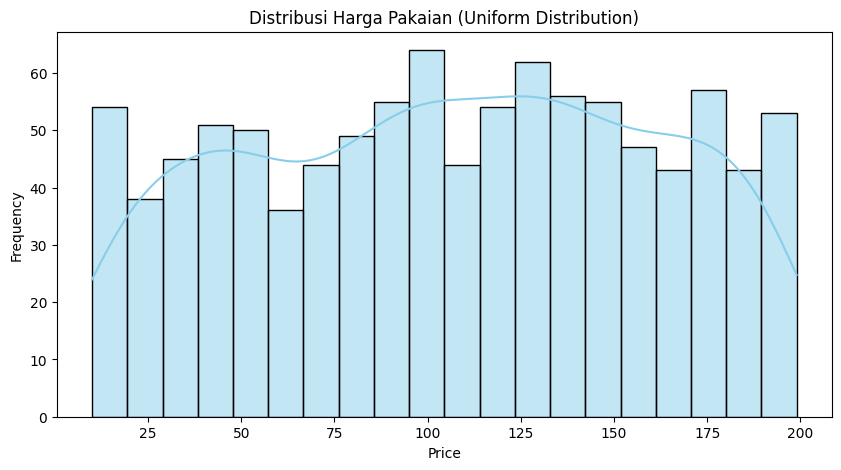

In [17]:
# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# 1. Distribusi Price (histogram + KDE)
plt.figure(figsize=(10, 5))
sns.histplot(df["Price"], kde=True, bins=20, color="skyblue")
plt.title("Distribusi Harga Pakaian (Uniform Distribution)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()



/tmp/ipykernel_3875/1154502994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="Price", data=df, ax=axes[i], palette="Set2")
/tmp/ipykernel_3875/1154502994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="Price", data=df, ax=axes[i], palette="Set2")
/tmp/ipykernel_3875/1154502994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y="Price", data=df, ax=axes[i], palette="Set2")
/tmp/ipykernel_3875/1154502994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

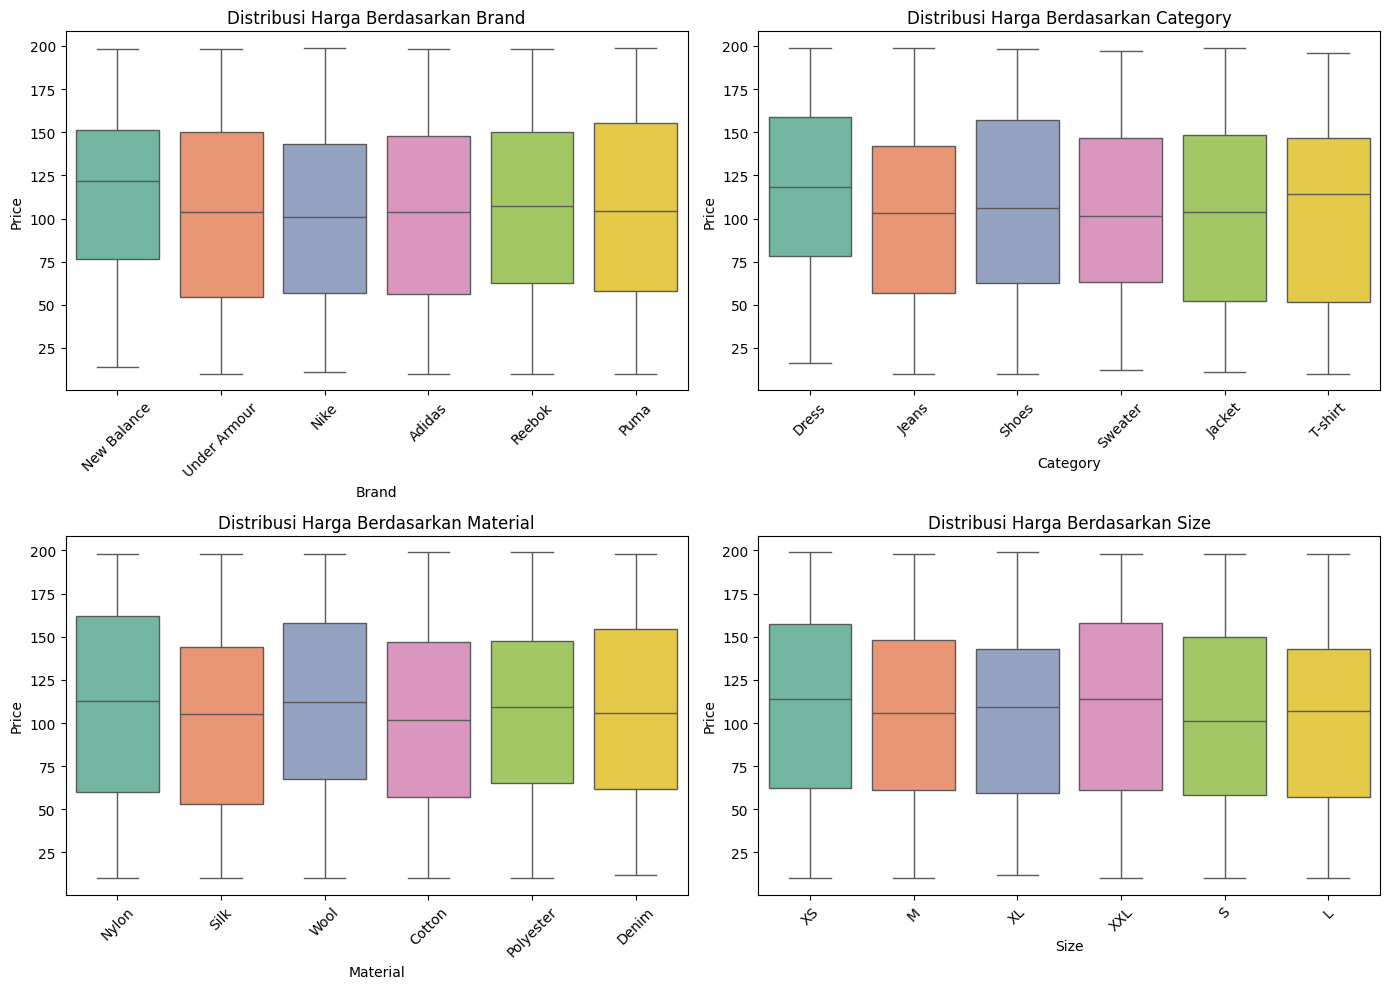

In [18]:
# 2. Boxplot: Analisis Korelasi Fitur Kategorikal vs Harga
print("\n")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

categorical_features = ["Brand", "Category", "Material", "Size"]

for i, col in enumerate(categorical_features):
    sns.boxplot(x=col, y="Price", data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"Distribusi Harga Berdasarkan {col}")
    axes[i].set_ylabel("Price")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# ==========================================
# 3b. STATISTIK DESKRIPTIF PER KATEGORI
# ==========================================
print("--- Bukti Matematis Keseragaman Data ---")

print("\n1. Mean & Std Price per Brand:")
display(df.groupby("Brand")["Price"].agg(["mean", "std"]).round(2))

print("\n2. Mean & Std Price per Category:")
display(df.groupby("Category")["Price"].agg(["mean", "std"]).round(2))

print("\n3. Mean & Std Price per Material:")
display(df.groupby("Material")["Price"].agg(["mean", "std"]).round(2))

--- Bukti Matematis Keseragaman Data ---

1. Mean & Std Price per Brand:


,mean,std
Brand,,
Adidas,104.05,53.21
New Balance,115.46,49.87
Nike,101.91,53.41
Puma,106.14,53.96
Reebok,106.49,53.73
Under Armour,103.96,57.16



2. Mean & Std Price per Category:


,mean,std
Category,,
Dress,114.51,51.14
Jacket,102.83,55.62
Jeans,100.75,51.95
Shoes,108.57,54.75
Sweater,106.78,51.75
T-shirt,104.56,56.39



3. Mean & Std Price per Material:


,mean,std
Material,,
Cotton,103.35,54.39
Denim,107.69,51.53
Nylon,109.39,56.40
Polyester,106.43,52.18
Silk,101.91,54.79
Wool,109.20,53.30


In [40]:
# ==========================================
# 4. PREPROCESSING
# ==========================================
print("\n--- Preprocessing Data ---")

# 1. Pisah fitur (X) dan target (y)
X = df.drop(columns=["Price"])
y = df["Price"]

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 3. Setup Encoding untuk fitur kategorikal
# Kategori Nominal (Tidak ada tingkatan): Brand, Category, Color, Material
categorical_cols = ["Brand", "Category", "Color", "Material"]

# Kategori Ordinal (Ada hierarki ukuran): Size
size_order = ["XS", "S", "M", "L", "XL", "XXL"]

# 4. Membangun ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encoding (drop='first' untuk menghindari Multicollinearity)
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        # Ordinal encoding sesuai urutan hierarki
        ("ord", OrdinalEncoder(categories=[size_order]), ["Size"])
    ],
    remainder="passthrough"
)

print(f"Dimensi X_train: {X_train.shape[0]} baris")
print(f"Dimensi X_test: {X_test.shape[0]} baris")
print("Preprocessing selesai: One-Hot Encoding + Ordinal Encoding siap digunakan dalam Pipeline.")


--- Preprocessing Data ---
Dimensi X_train: 800 baris
Dimensi X_test: 200 baris
Preprocessing selesai: One-Hot Encoding + Ordinal Encoding siap digunakan dalam Pipeline.


In [41]:
# ==========================================
# 5. MODELING (TRAINING PIPELINES & STACKING)
# ==========================================
from sklearn.ensemble import StackingRegressor # <-- Import baru

print("\n--- Training Models ---")

def make_pipeline(model_name, regressor):
    if model_name == "ElasticNet":
        return Pipeline([
            ("preprocessor", preprocessor),
            ("scaler", StandardScaler(with_mean=False)),
            ("regressor", regressor)
        ])
    else:
        return Pipeline([
            ("preprocessor", preprocessor),
            ("regressor", regressor)
        ])

# --- MEMBUAT MODEL STACKING ---
# Level 0 (Base Learners): Random Forest & LightGBM
base_estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('lgbm', lgb.LGBMRegressor(random_state=42, n_estimators=100, n_jobs=-1, force_col_wise=True))
]

# Level 1 (Meta Learner): ElasticNet
meta_learner = ElasticNet(random_state=42, max_iter=2000)

# Bungkus menjadi satu Stacking Regressor
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5 # Cross-validation 5 fold saat melatih meta-learner
)

# Inisialisasi Semua Model (Bandingkan model individu vs Stacking)
models = {
    "Dummy": DummyRegressor(strategy="mean"),
    "ElasticNet": ElasticNet(random_state=42, max_iter=2000),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(random_state=42, n_estimators=100, n_jobs=-1, force_col_wise=True),
    "Stacking (RF+LGBM -> EN)": stacking_model # <-- Model jagoan kita dimasukkan
}

# Proses Training
trained_pipelines = {}
for name, model in models.items():
    pipe = make_pipeline(name, model)
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f"✅ {name} berhasil dilatih.")


--- Training Models ---
✅ Dummy berhasil dilatih.
✅ ElasticNet berhasil dilatih.
✅ Random Forest berhasil dilatih.
[LightGBM] [Info] Total Bins 46
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 21
[LightGBM] [Info] Start training from score 106.632500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [46]:
# ==========================================
# 6. EVALUATION METRICS
# ==========================================
from sklearn.metrics import mean_absolute_percentage_error

print("\n--- Evaluasi Performa Model ---")

def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    # Kalkulasi Metrik
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape * 100, # Jadikan format persentase
        "R-Squared": r2
    }

# 1. Hitung metrik untuk semua model
results = []
for name, model in trained_pipelines.items():
    res = evaluate(model, X_test, y_test, name)
    results.append(res)
    print(f"✅ {name:15} | RMSE: {res['RMSE']:.2f} | MAE: {res['MAE']:.2f} | MAPE: {res['MAPE (%)']:.2f}% | R²: {res['R-Squared']:.4f}")

# 2. Tabel perbandingan model
df_results = pd.DataFrame(results)
print("\n--- Tabel Perbandingan Model ---")
display(df_results.round(4))


--- Evaluasi Performa Model ---
✅ Dummy           | RMSE: 54.16 | MAE: 46.18 | MAPE: 101.65% | R²: -0.0010
✅ ElasticNet      | RMSE: 54.05 | MAE: 46.18 | MAPE: 100.97% | R²: 0.0031
✅ Random Forest   | RMSE: 57.48 | MAE: 48.07 | MAPE: 109.56% | R²: -0.1275
✅ LightGBM        | RMSE: 56.79 | MAE: 47.80 | MAPE: 102.83% | R²: -0.1004
✅ Stacking (RF+LGBM -> EN) | RMSE: 54.13 | MAE: 46.15 | MAPE: 101.74% | R²: 0.0000

--- Tabel Perbandingan Model ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,RMSE,MAE,MAPE (%),R-Squared
0,Dummy,54.1613,46.1760,101.6531,-0.0010
1,ElasticNet,54.0511,46.1839,100.9731,0.0031
2,Random Forest,57.4817,48.0707,109.5636,-0.1275
3,LightGBM,56.7870,47.8039,102.8309,-0.1004
4,Stacking (RF+LGBM -> EN),54.1332,46.1539,101.7367,0.0000



--- Visualisasi Performa Model ---


/tmp/ipykernel_3875/4193542354.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="RMSE", data=df_results, ax=axes[0], palette="Blues_d")
/tmp/ipykernel_3875/4193542354.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="MAPE (%)", data=df_results, ax=axes[1], palette="Greens_d")
/tmp/ipykernel_3875/4193542354.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="R-Squared", data=df_results, ax=axes[2], palette="Reds_d")


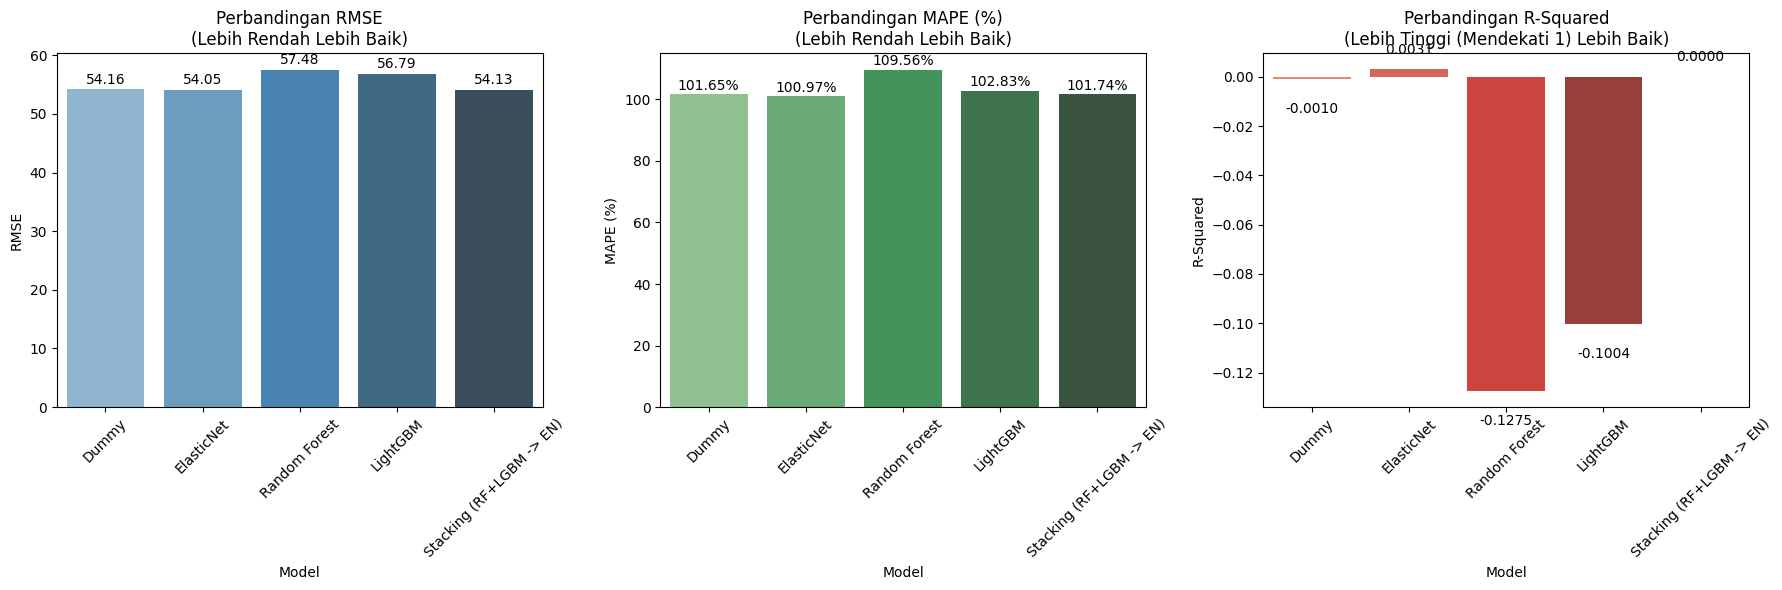

In [44]:
# ==========================================
# 7. VISUALIZATION OF MODEL PERFORMANCE
# ==========================================
print("\n--- Visualisasi Performa Model ---")

# Buat 3 subplot untuk RMSE, MAPE, dan R-Squared
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Plot RMSE
sns.barplot(x="Model", y="RMSE", data=df_results, ax=axes[0], palette="Blues_d")
axes[0].set_title("Perbandingan RMSE\n(Lebih Rendah Lebih Baik)")
axes[0].tick_params(axis="x", rotation=45)
# Tambahkan label angka di atas bar
for i, v in enumerate(df_results["RMSE"]):
    axes[0].text(i, v + 0.5, f"{v:.2f}", ha='center', va='bottom', fontsize=10)

# 2. Plot MAPE
sns.barplot(x="Model", y="MAPE (%)", data=df_results, ax=axes[1], palette="Greens_d")
axes[1].set_title("Perbandingan MAPE (%)\n(Lebih Rendah Lebih Baik)")
axes[1].tick_params(axis="x", rotation=45)
for i, v in enumerate(df_results["MAPE (%)"]):
    axes[1].text(i, v + 0.5, f"{v:.2f}%", ha='center', va='bottom', fontsize=10)

# 3. Plot R-Squared
sns.barplot(x="Model", y="R-Squared", data=df_results, ax=axes[2], palette="Reds_d")
axes[2].set_title("Perbandingan R-Squared\n(Lebih Tinggi (Mendekati 1) Lebih Baik)")
axes[2].tick_params(axis="x", rotation=45)
for i, v in enumerate(df_results["R-Squared"]):
    # Menggeser sedikit posisi text untuk mengakomodasi angka negatif/kecil
    offset = 0.005 if v > 0 else -0.015
    axes[2].text(i, v + offset, f"{v:.4f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()